# SAMSUNG SALES FORECASTING(TIME SERIES ANALYSIS)

## Project summary
This project develops a time series forecasting framework to predict Samsung product revenue for 2025. The dataset consists of synthetic sales transactions spanning 2021–2024, covering multiple Samsung product categories including Galaxy S, Z Fold/Flip, Galaxy A/M, Tablets, Watches, Buds, Smart TVs, Monitors, and Home Appliances. The data is hierarchically structured across 52 countries and 555+ cities, organized by Country → City → Date, enabling both regional and global demand analysis.

The analysis involves time series decomposition, trend and seasonality analysis, and feature engineering to capture temporal sales patterns across markets. Forecasting models such as ARIMA/SARIMA, Prophet, and machine learning–based approaches will be evaluated to identify the most robust predictive framework.

The resulting model aims to generate accurate revenue forecasts for 2025, providing insights that can support data-driven marketing strategies, demand planning, and inventory optimization across international markets.

## 1. Business Understanding

The objective of this project is to support data-driven decision making in product restocking, demand planning, and regional sales strategy. Without systematic analysis, inventory and marketing decisions may rely on assumptions rather than empirical evidence, potentially leading to overstocking, stockouts, or inefficient resource allocation.

Using the sales transaction dataset, we aim to analyze product-level and regional demand patterns across multiple markets. This includes identifying high-performing product categories, determining which products generate the highest sales volumes, and understanding geographical demand distribution across countries and cities.

### Main Objectives
 - To build a time series that forecasts sales figures for the next month
 - To evaluate best perfoming sities and products
 - To provide actionable insights to support better financial and resource allotcation
 - To create a forecasting dashboard

#### objective
- 5G Adoption by Country — Which markets lead in 5G device sales?
- Foldable Trends (Galaxy Z) — Growth of Z Fold vs Z Flip year-over-year
- Budget vs Flagship Split — Galaxy A/M vs Galaxy S revenue share
- Samsung Pay Adoption — Payment method preference by region
- Revenue by City — Top 20 cities by total Samsung revenue
- Category Mix — Phone vs TV vs Appliance share by country
- Seasonality Analysis — Q4 vs Q1/Q2/Q3 across product lines
- Discount Impact — Higher discount % → more units but lower margin?
- OS Switching — What % of Galaxy S buyers switched from iOS?
- Return Rate by Category — Which product has highest return rate?
- Age Group Preferences — 18–24 prefers Galaxy A; 35+ prefers Galaxy S?
- Multi-Year Trend — Revenue growth 2021 → 2024


### Metrics of success

## 2. Data understanding
The datsaset is from kaggle [Samsung Global Product Sales](https://www.kaggle.com/datasets/ashyou09/samsung-global-product-sales-dataset). This dataset simulates a realistic global sales ledger for Samsung Electronics products.

**Features**

**sale_id** - 
**sale_date** - date of the sale
**year** -year of the sale
**quarter** -quarter of the sale
**month** - month of the sale
**country**
**region**
**city** 
**product_name** 
**category** '
**storage**
**color**
**is_5g**
**unit_price_usd**
**discount_pct**
**units_sold**
**discounted_price_usd**
**revenue_usd**, '
**currency**, '
**fx_rate_to_usd**, '
**revenue_local_currency**,
**sales_channel**, '
**payment_method**, '
**customer_segment**,
**customer_age_group** '
**previous_device_os**
**customer_rating**
**return_status**

 >### **2.1 Load the dataset**

In [2]:
# import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [3]:
# read the dataset
data = pd.read_csv("samsung_global_sales_dataset.csv")
# review the first few rows of the dataset
data.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


>### **2.2 Dataframe shape**
We evaluate the shape of our dataset to identify the number of ros and columns

In [4]:
# shape of dataframe
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

Rows: 15500
Columns: 28


>### 2.3 Dataset Information

We examine the general overview of the dataset, data types and missing values

In [5]:
#general overview of th dataframe
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  str    
 1   sale_date               15500 non-null  str    
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  str    
 4   month                   15500 non-null  str    
 5   country                 15500 non-null  str    
 6   region                  15500 non-null  str    
 7   city                    15500 non-null  str    
 8   product_name            15500 non-null  str    
 9   category                15500 non-null  str    
 10  storage                 7651 non-null   str    
 11  color                   15500 non-null  str    
 12  is_5g                   15500 non-null  str    
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null  int64  
 

>### 2.4 Dataset General Statistics
>We generate the descriptive statistics of the dataset to understand the distribution of numerical features

In [6]:
# general statistics
data.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,11249.000000
mean,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.743515
std,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.721258
min,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.100000
50%,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.400000
max,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000


from the above analysis we can see there are some large outliers on the `revenue_local_currency`, `fx_rate_to_usd`, `revenue_usd` and `discounted_price_usd` 

>### 2.5 Check for missing values

In [7]:
#check for missing values
print(f"The dataset contains { data.isnull().sum().sum()} missing values")

The dataset contains 21473 missing values


In [8]:
data.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   7849
color                        0
is_5g                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        9373
customer_rating           4251
return_status                0
dtype: int64

From the above info we note that the `storage`, `previous_device_os`  columns have over half of the data missing 

>### 2.6 Check for duplicates

In [9]:
print(f"The dataset contains {data.duplicated().sum()} duplicate values")

The dataset contains 0 duplicate values


## 3. Data Cleaning

In this step we clean the dataset by handling missing values, duplicate values, standardizing dat, dropping irrelevant columns and addressing any other issue to ensure that the data is reliable and ready for further analysis

>### 3.1 Handling missing values and duplicates
>Our dataset does not contain any duplicate but has a lot of  missing values in specific columns. The most appropriate way is to drop the columns that habe a lot of missing values.

In [10]:
data = data.drop(['previous_device_os' , 'storage'] , axis =1) 

>### 3.2 Change the data types of `month`, `year`, `sale_date` to time

In [11]:
data['month'].dtype

<StringDtype(storage='python', na_value=nan)>

In [12]:
data['year'].value_counts()

year
2022    3957
2024    3912
2023    3871
2021    3760
Name: count, dtype: int64

In [13]:
data.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'color', 'is_5g', 'unit_price_usd',
       'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd',
       'currency', 'fx_rate_to_usd', 'revenue_local_currency', 'sales_channel',
       'payment_method', 'customer_segment', 'customer_age_group',
       'customer_rating', 'return_status'],
      dtype='str')

In [14]:
data['sale_date'] = pd.to_datetime(data['sale_date'])

>### 3.3 Rename relevant columns and drop irrelevant ones
> Drop the `customer segment` column since we will not be doing market segmentation

In [15]:
data = data.drop(['customer_segment','revenue_local_currency'],axis = 1)

>### Evaluate entries in `Countries`, `city`, `region`, `product_name` columns 

In [16]:
data['country'].value_counts()

country
Norway            328
Indonesia         326
Canada            323
Sri Lanka         318
Austria           317
Greece            317
Pakistan          314
France            313
Turkey            313
India             311
Egypt             309
Taiwan            309
Vietnam           308
Ethiopia          307
Italy             307
Nigeria           307
Australia         306
Poland            303
UAE               303
United States     303
Kenya             302
Thailand          301
Japan             299
Argentina         298
Germany           298
Malaysia          298
South Korea       298
Czech Republic    297
Colombia          296
Belgium           295
New Zealand       295
United Kingdom    295
Chile             294
Russia            294
Ukraine           293
Brazil            292
Peru              290
Spain             290
Mexico            287
Philippines       287
South Africa      287
Bangladesh        286
Myanmar           286
Saudi Arabia      286
Switzerland       285
Ro

In [17]:
data['region'].value_counts()

region
Europe           5327
Asia             4481
Africa           1512
South America    1470
North America     913
Europe/Asia       607
Oceania           601
Middle East       589
Name: count, dtype: int64

In [18]:
data['product_name'].value_counts()

product_name
Samsung Galaxy Tab S9 FE        250
Samsung Galaxy M04              241
Samsung Galaxy Buds Live        234
Samsung Wireless Charger Pad    233
Samsung Galaxy S23 FE           232
                               ... 
Samsung Smart Tag 2             189
Samsung Galaxy A14 5G           189
Samsung Odyssey Neo G9          188
Samsung Galaxy Tab S8 Ultra     183
Samsung Galaxy S21 FE           169
Name: count, Length: 73, dtype: int64

In [19]:
data['category'].value_counts()

category
Galaxy S        2316
Accessories     2101
Galaxy A        1892
Galaxy Tab      1524
Galaxy Watch    1486
Smart TV        1295
Galaxy Z        1058
Appliances      1052
Monitor         1046
Galaxy Buds      869
Galaxy M         861
Name: count, dtype: int64

### 4.1 Univariate Analysis
Univariate analysis involves examining the distribution and summary statistics of individual variables.

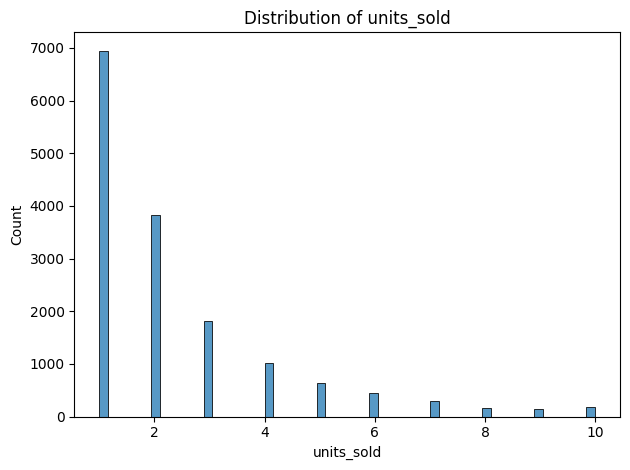

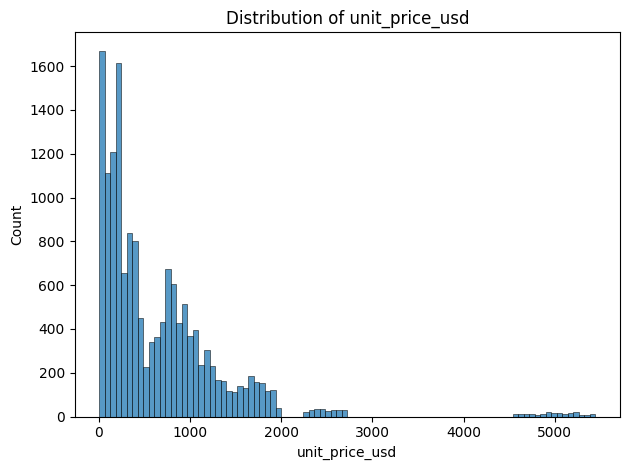

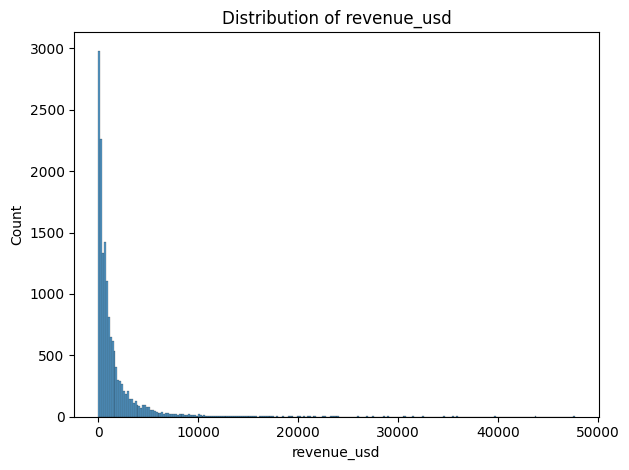

In [20]:
numeric_cols = data[['units_sold', 'unit_price_usd', 'revenue_usd']]
for cols in numeric_cols:
    plot = sns.histplot(data= numeric_cols, x= cols)
    plot.set_title(f"Distribution of {cols}")
    plt.tight_layout()
    plt.show()

>### 4.1 Average Monthly Quantity
>we will evaluate and visualize the average monthly quantity sold, using a line plot and bar plot|
 

In [21]:
#function for monthly average : Quantity sold, amount
import random
import calendar

def monthly_average(numerical_input):
    temp_df = data.copy()
    
    # Extract month from sale_date column
    temp_df['month_num'] = temp_df['sale_date'].dt.month
    temp_df['month'] = temp_df['month_num'].apply(lambda x: calendar.month_name[x])
    
    # Create ordered categorical for proper month ordering
    temp_df['month'] = pd.Categorical(temp_df['month'], 
                                       categories=list(calendar.month_name)[1:],
                                       ordered=True)
    
    monthly_avg = temp_df.groupby("month")[numerical_input].mean().reset_index()

    palette = sns.color_palette("hls")
    random_color = random.choice(palette)
    random_color2 = random.choice(palette)

    figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), sharey=True)

    sns.lineplot(data=monthly_avg, x="month", y=numerical_input, 
                 color=random_color, marker="o", ax=axes[0])
    axes[0].set_title(f"Monthly {numerical_input} - Lineplot", fontsize=16)
    axes[0].set_xlabel("Month", fontsize=12)
    axes[0].set_ylabel(numerical_input, fontsize=12)
    axes[0].tick_params(axis='x', labelsize=10, rotation=45)
    axes[0].grid(True)

    sns.barplot(data=monthly_avg, x="month", y=numerical_input, 
                color=random_color2, ax=axes[1])
    axes[1].set_title(f"Monthly {numerical_input} - Barplot", fontsize=16)
    axes[1].set_xlabel("Month", fontsize=12)
    axes[1].set_ylabel(numerical_input, fontsize=12)
    axes[1].tick_params(axis='x', labelsize=10, rotation=45)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

>### 4.2 Average Weekly Sales
>Visualize average weekly sales using line and bar plots

In [22]:
#function for weekly average : Quantity sold, amount
def weekly_average(numerical_input):
    temp_df = data.copy()
    
    # Extract week number and year from sale_date
    temp_df['year'] = temp_df['sale_date'].dt.year
    temp_df['week'] = temp_df['sale_date'].dt.isocalendar().week
    
    # Create a combined year-week label for better visualization
    temp_df['year_week'] = temp_df['year'].astype(str) + '-W' + temp_df['week'].astype(str).str.zfill(2)
    
    # Group by year_week and calculate mean
    weekly_avg = temp_df.groupby("year_week")[numerical_input].mean().reset_index()
    
    # Sort by year_week
    weekly_avg = weekly_avg.sort_values('year_week').reset_index(drop=True)
    
    # For visualization, show last 20 weeks if data is too large
    if len(weekly_avg) > 20:
        weekly_avg_display = weekly_avg.tail(20)
    else:
        weekly_avg_display = weekly_avg

    palette = sns.color_palette("hls")
    random_color = random.choice(palette)
    random_color2 = random.choice(palette)

    figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), sharey=True)

    # Line plot
    sns.lineplot(data=weekly_avg_display, x="year_week", y=numerical_input, 
                 color=random_color, marker="o", ax=axes[0])
    axes[0].set_title(f"Weekly {numerical_input} - Lineplot", fontsize=16)
    axes[0].set_xlabel("Year-Week", fontsize=12)
    axes[0].set_ylabel(numerical_input, fontsize=12)
    axes[0].tick_params(axis='x', labelsize=9, rotation=45)
    axes[0].grid(True)

    # Bar plot
    sns.barplot(data=weekly_avg_display, x="year_week", y=numerical_input, 
                color=random_color2, ax=axes[1])
    axes[1].set_title(f"Weekly {numerical_input} - Barplot", fontsize=16)
    axes[1].set_xlabel("Year-Week", fontsize=12)
    axes[1].set_ylabel(numerical_input, fontsize=12)
    axes[1].tick_params(axis='x', labelsize=9, rotation=45)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

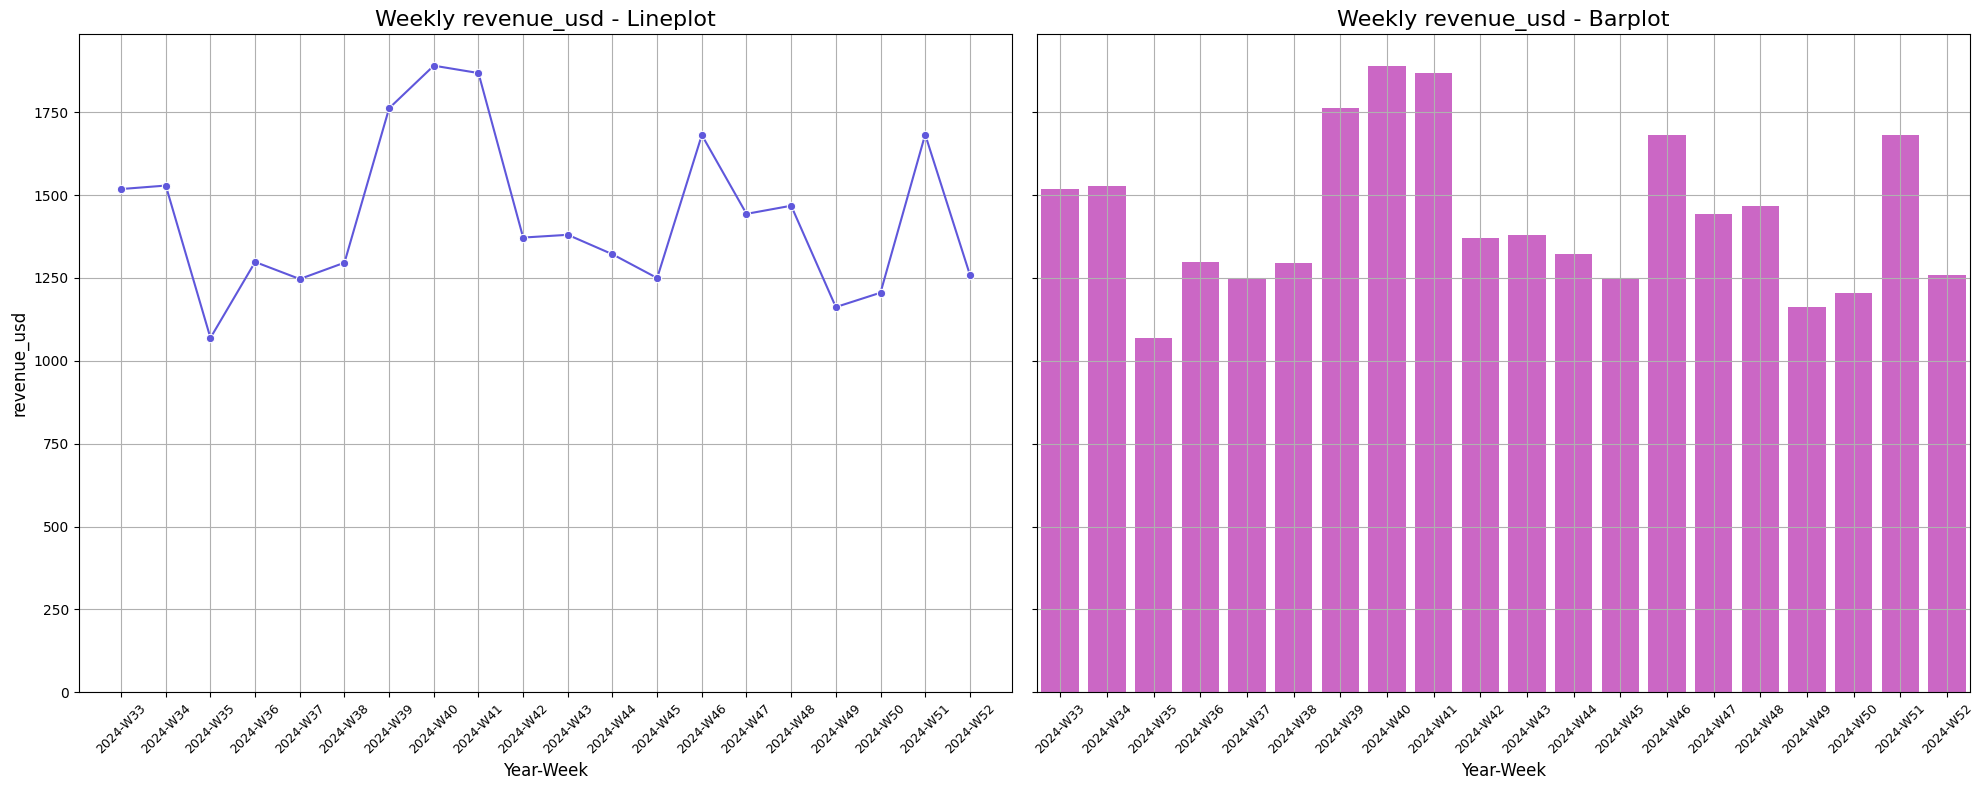

In [23]:
#evaluate average weekly quantity
weekly_average('revenue_usd')

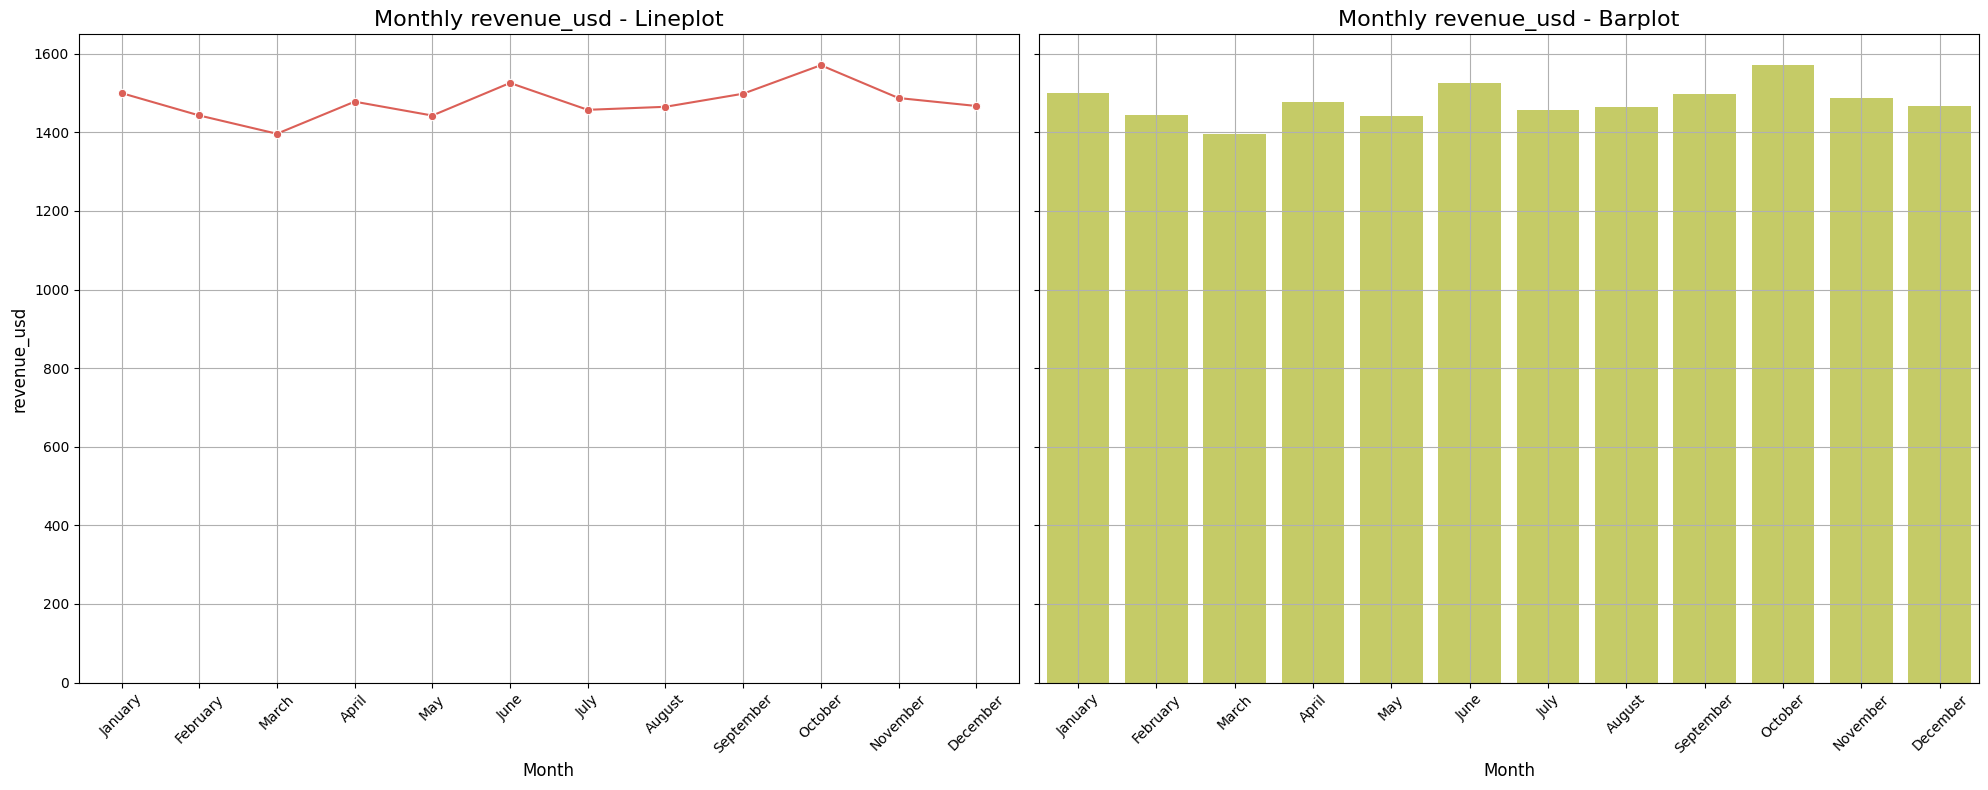

In [24]:
#evaluate average monthly quantity
monthly_average('revenue_usd')

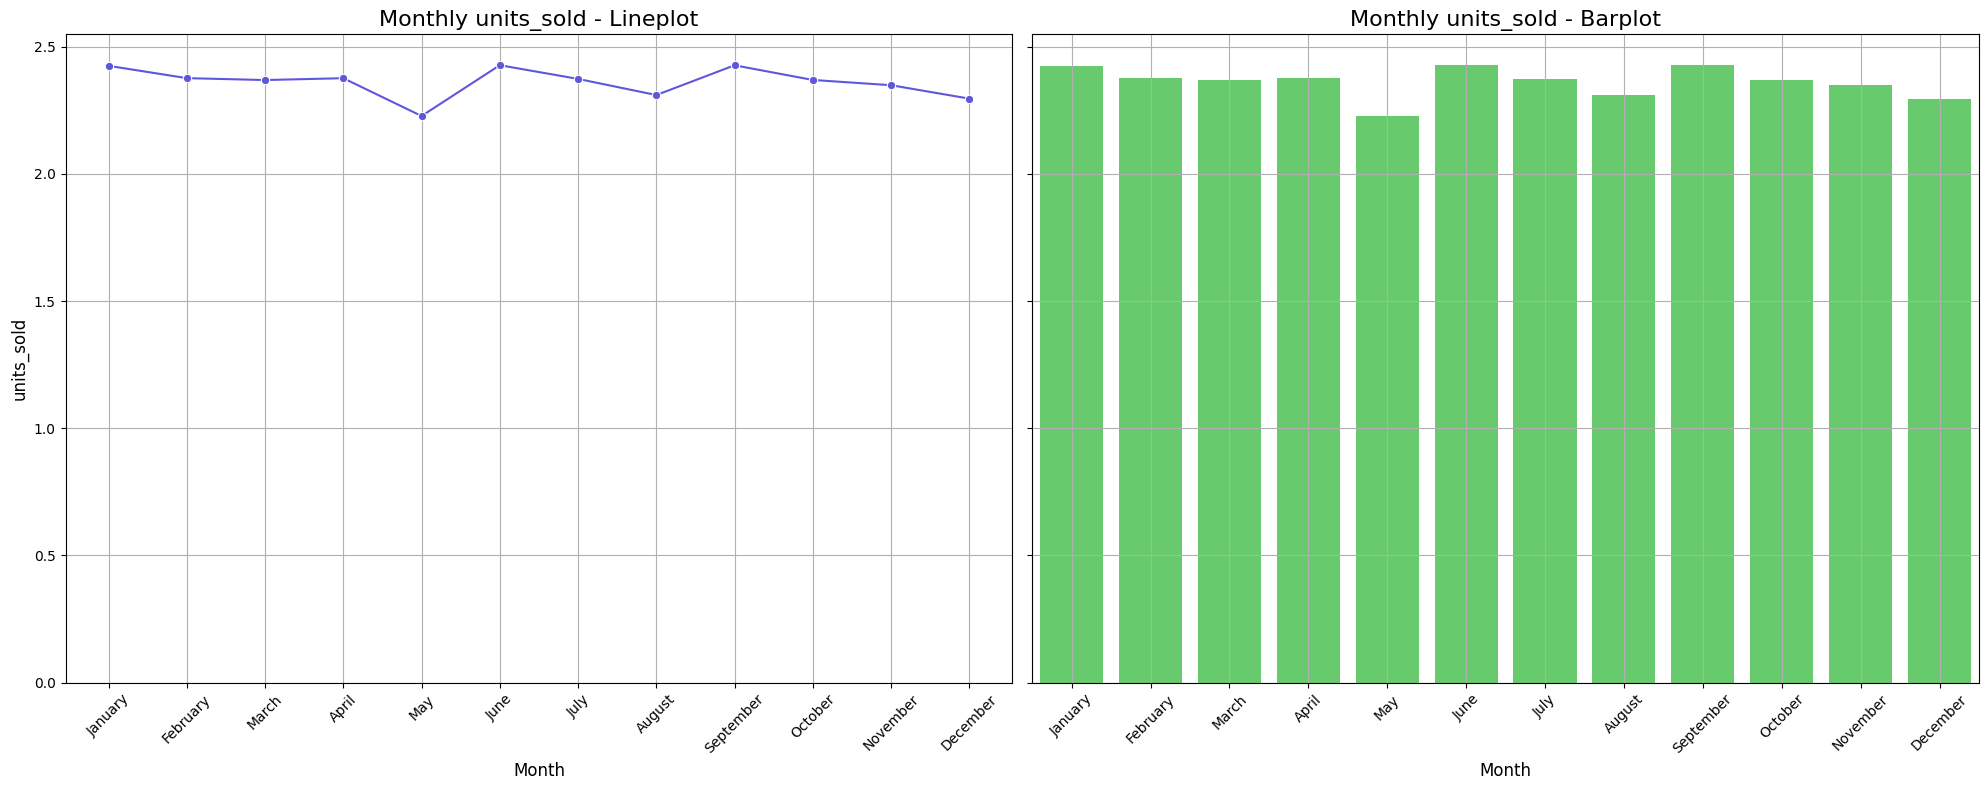

In [25]:
monthly_average('units_sold')

>### 4.1.2 Average Weekly Sales Amount and Quantity Sold
>visualising the weekly_average sales for each week

In [26]:
## Average Weekly

#function for weekly average : Quantity sold, amount
def weekly_average_sales(numerical_input):
    temp_df = data.copy()
    
    # Extract week number from sale_date column
    temp_df["Week"] = temp_df['sale_date'].dt.isocalendar().week
    weekly_avg = temp_df.groupby("Week")[numerical_input].mean().reset_index()

    palette = sns.color_palette("Set1")
    random_color = random.choice(palette)

    fig, ax = plt.subplots(figsize=(15, 8))

    sns.lineplot(data=weekly_avg, x='Week', y=numerical_input, 
                 color=random_color, ax=ax, marker='o')
    ax.set_title(f'Weekly Sales {numerical_input}', fontsize=16)
    ax.set_xlabel('Week', fontsize=12)
    ax.set_ylabel(f'{numerical_input}', fontsize=12)
    ax.tick_params(axis='both', labelsize=10)
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()

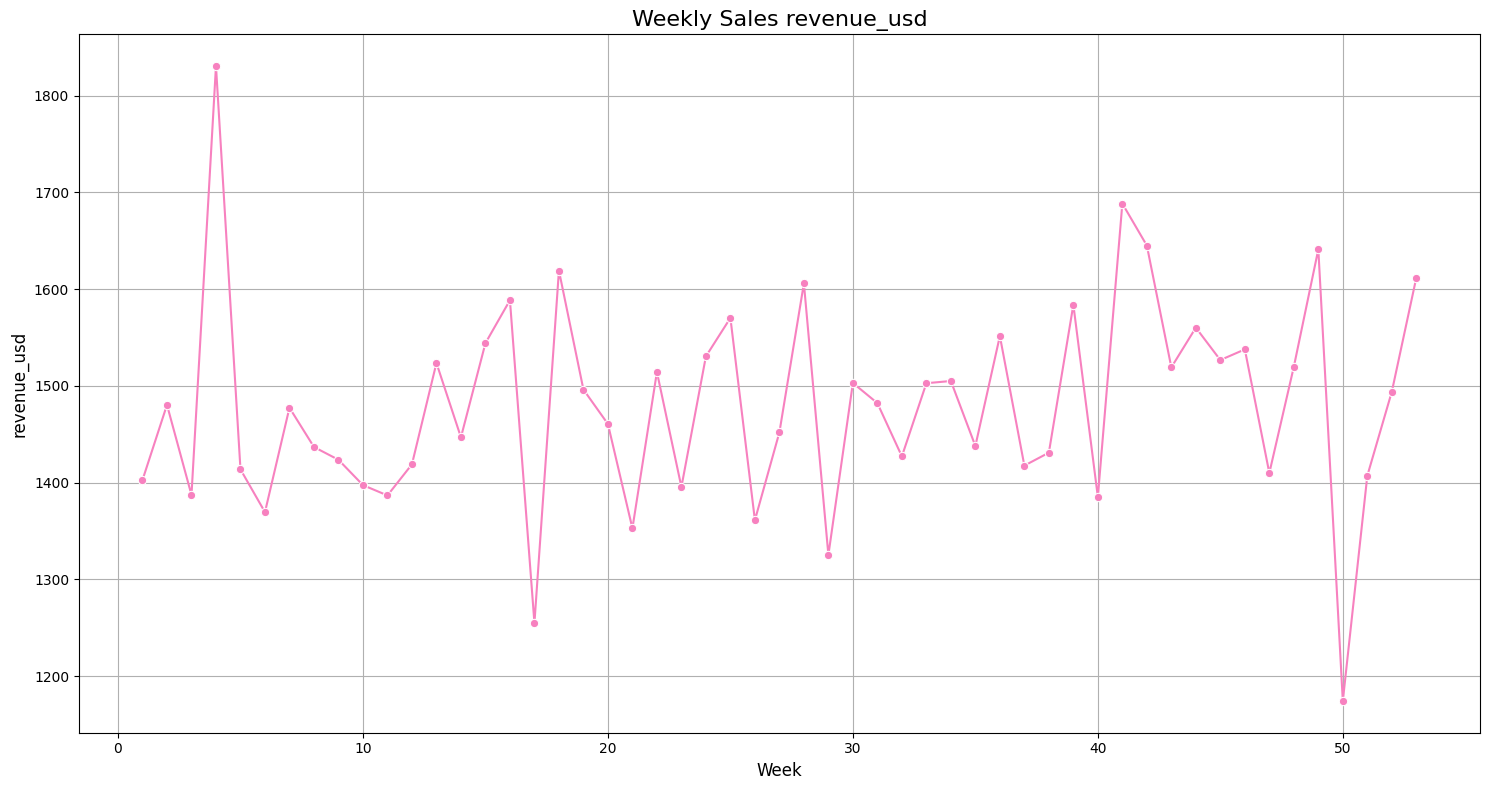

In [27]:
weekly_average_sales("revenue_usd")

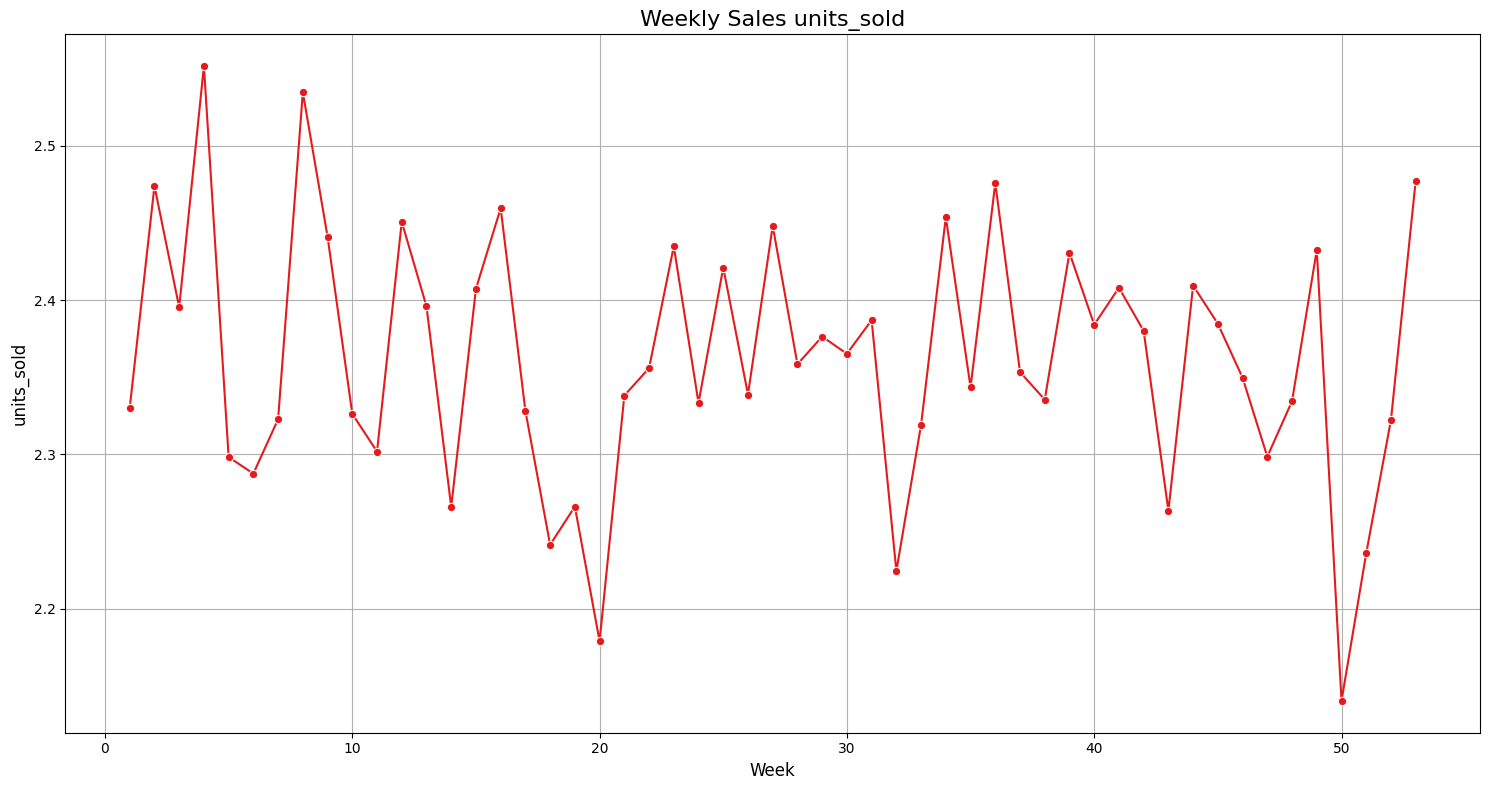

In [28]:
weekly_average_sales("units_sold")

**findings:**
- the average weekly sales spikes between week 0 and week 10,
- A steep negative slope is evident at week 50

>### 4.1.3 Average Daily Sales amount and quantity sold
>uses the `daily_average` function to visualize the average sales amount for each week


In [29]:
def daily_average(numerical_input, days_back=None):
    temp_df = data.copy()
    
    # Set sale_date as index for resampling
    temp_df = temp_df.set_index('sale_date')
    
    # Filter to recent days if specified
    if days_back is not None:
        cutoff_date = temp_df.index.max() - pd.Timedelta(days=days_back)
        temp_df = temp_df[temp_df.index >= cutoff_date]
    
    # Resample to daily frequency and calculate mean for numeric columns
    daily_avg = temp_df.select_dtypes(include=['number']).resample('D').mean()

    palette = sns.color_palette("deep")
    random_color = random.choice(palette)

    fig, ax = plt.subplots(figsize=(15, 8))

    sns.lineplot(data=daily_avg, x=daily_avg.index, y=numerical_input, 
                 color=random_color, ax=ax)

    ax.set_title(f"Daily Sale {numerical_input} - Last {days_back} Days" if days_back else f"Daily Sales {numerical_input} - Full Data", fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(numerical_input, fontsize=12)
    ax.tick_params(axis='both', labelsize=10)
    fig.autofmt_xdate()

    plt.grid(True)
    plt.tight_layout()
    plt.show()

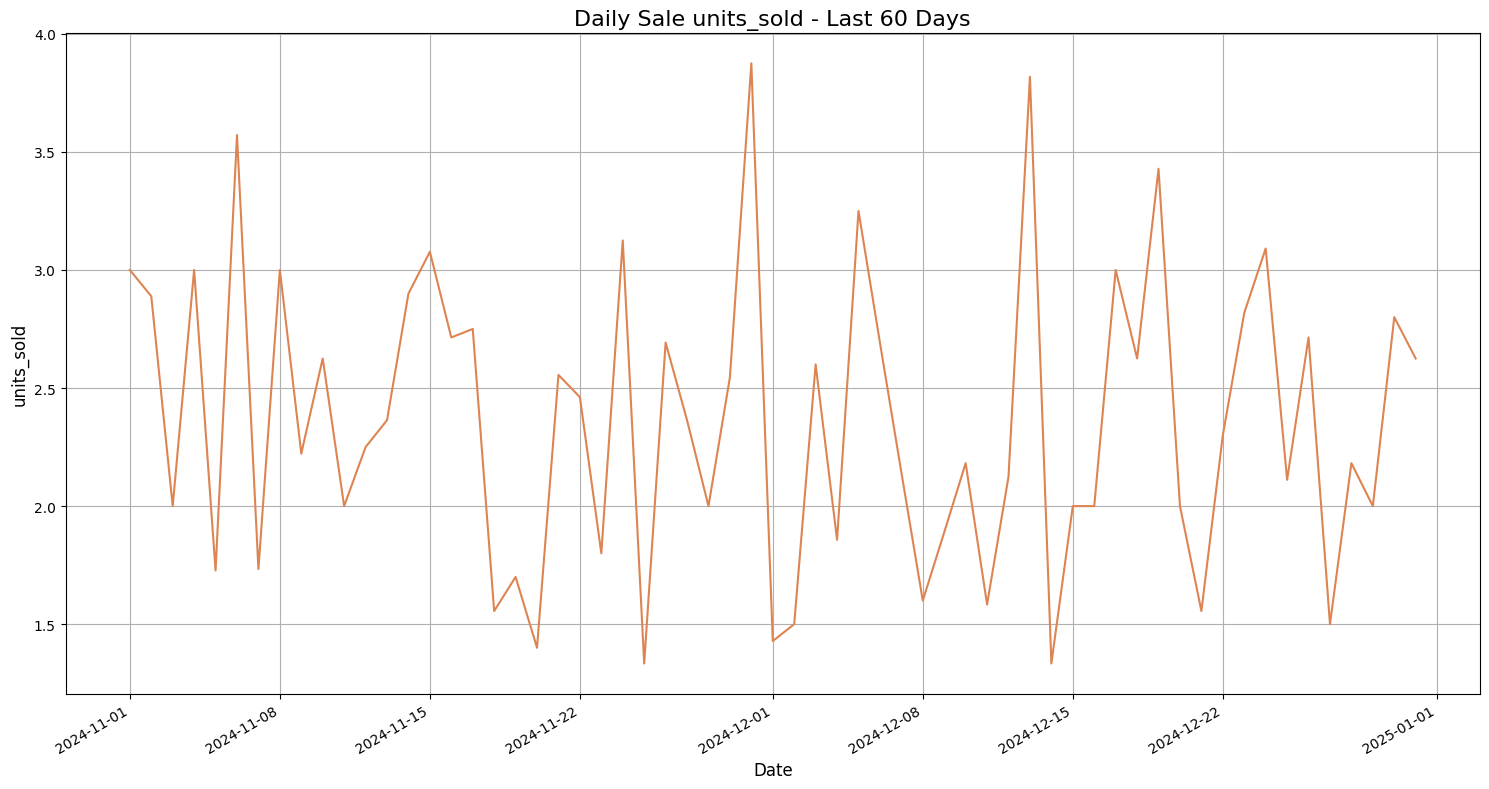

In [30]:
daily_average("units_sold", days_back=60)

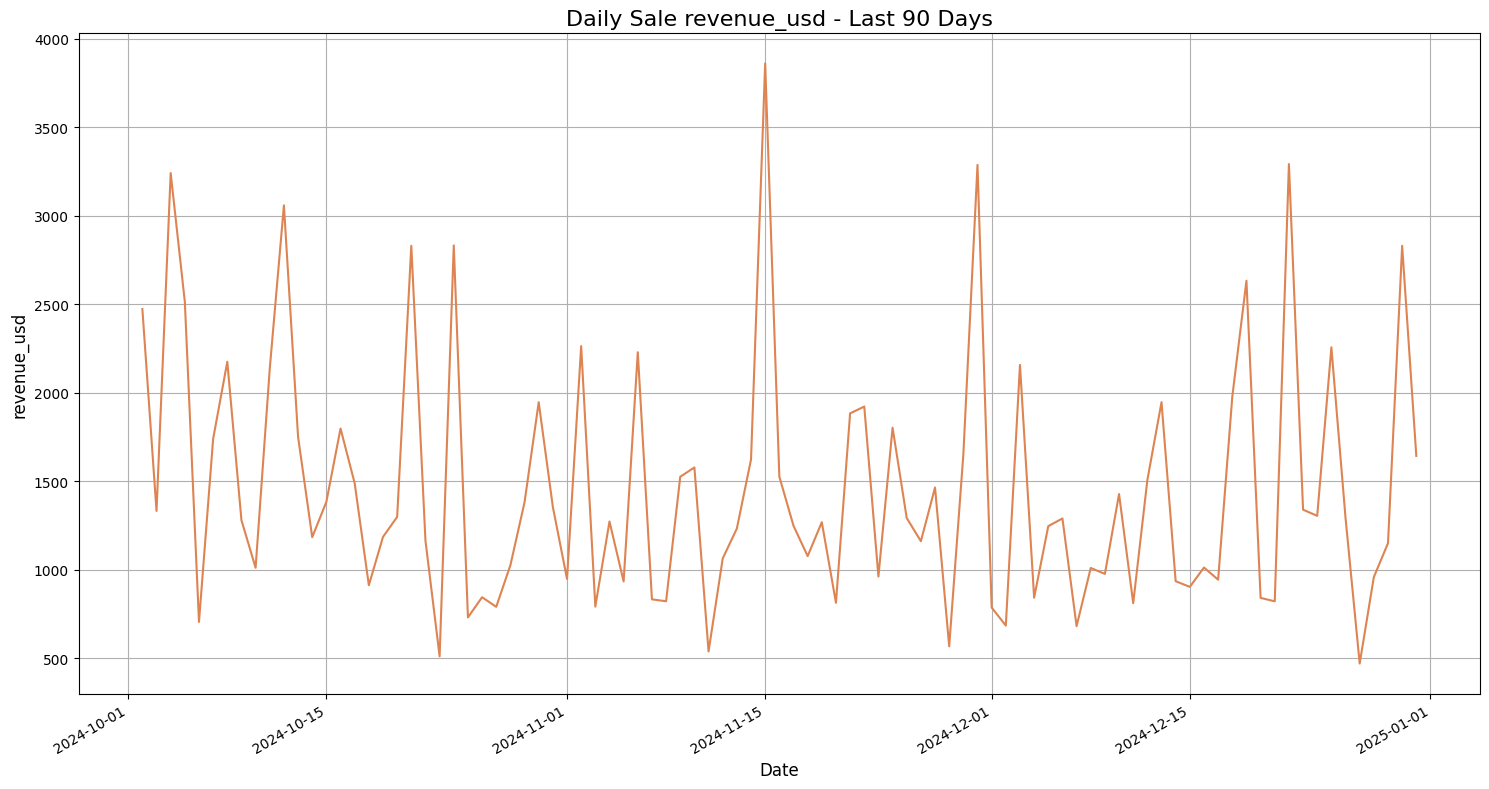

In [31]:
daily_average("revenue_usd" , days_back= 90)

graph for the daily TOTAl unit sold with a 7 day rolling mean

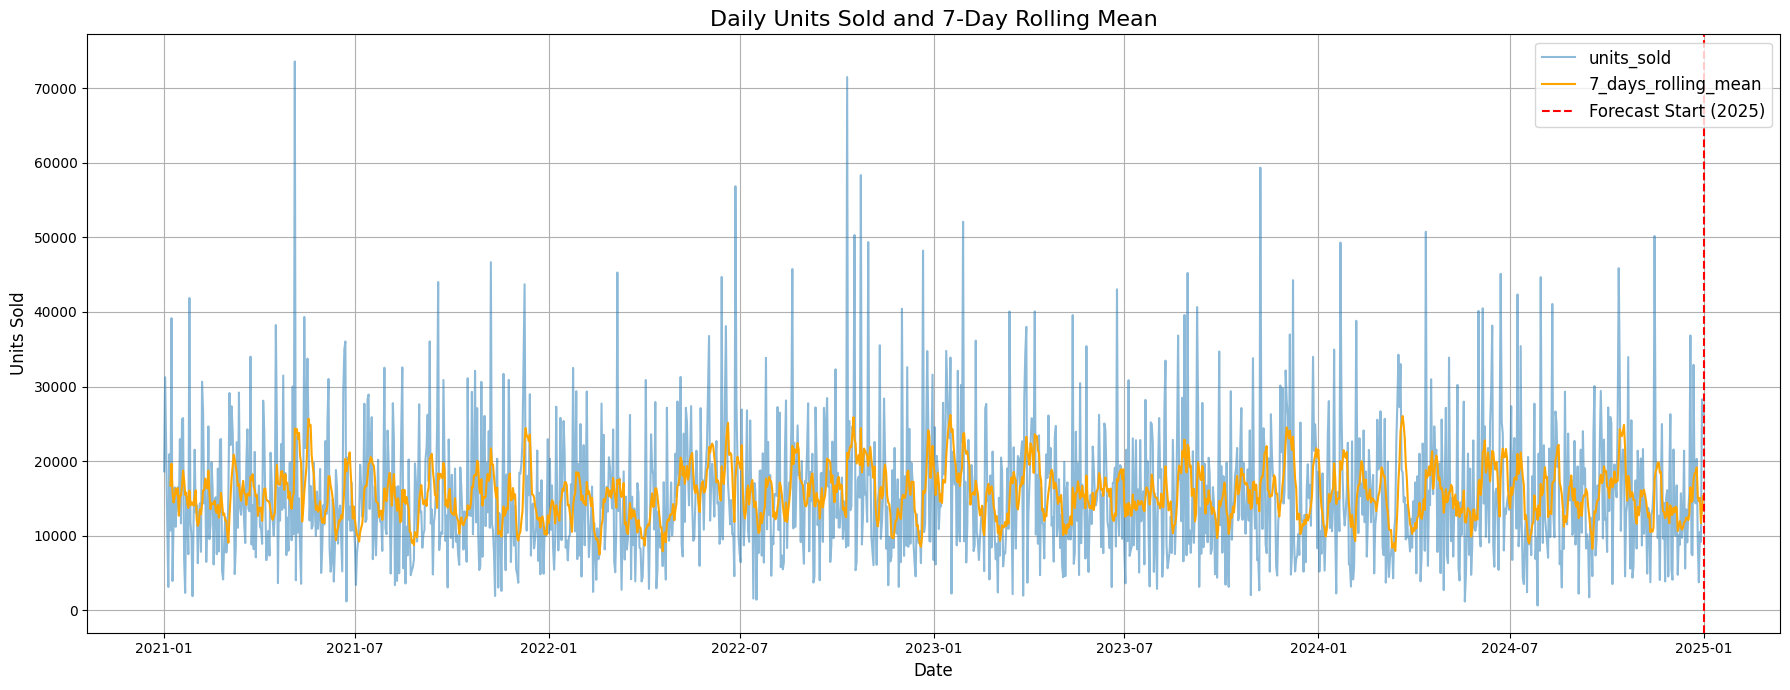

In [32]:
# Full range of dates
temp_df = data.copy()
temp_df = temp_df.set_index('sale_date')

full_range = pd.date_range(start=temp_df.index.min(), end=temp_df.index.max(), freq='D')

# Reindex to include all dates, filling missing with 0
daily_quantity = temp_df['revenue_usd'].resample('D').sum().reindex(full_range, fill_value=0)

# Compute rolling mean again
rolling_mean = daily_quantity.rolling(window=7).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 7))
plt.plot(daily_quantity.index, daily_quantity, label='units_sold', alpha=0.5)
plt.plot(rolling_mean.index, rolling_mean, label="7_days_rolling_mean", color='orange')
plt.axvline(pd.to_datetime('2025-01-01'), color='r', linestyle='--', label='Forecast Start (2025)')
plt.legend(fontsize=12)
plt.title('Daily Units Sold and 7-Day Rolling Mean', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.tick_params(labelsize=10)
plt.show()

>### 4.1.4 Best and worst selling Products
>This plot shows the top 10 best sellig products across the market 

In [33]:
data.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'color', 'is_5g', 'unit_price_usd',
       'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd',
       'currency', 'fx_rate_to_usd', 'sales_channel', 'payment_method',
       'customer_age_group', 'customer_rating', 'return_status'],
      dtype='str')

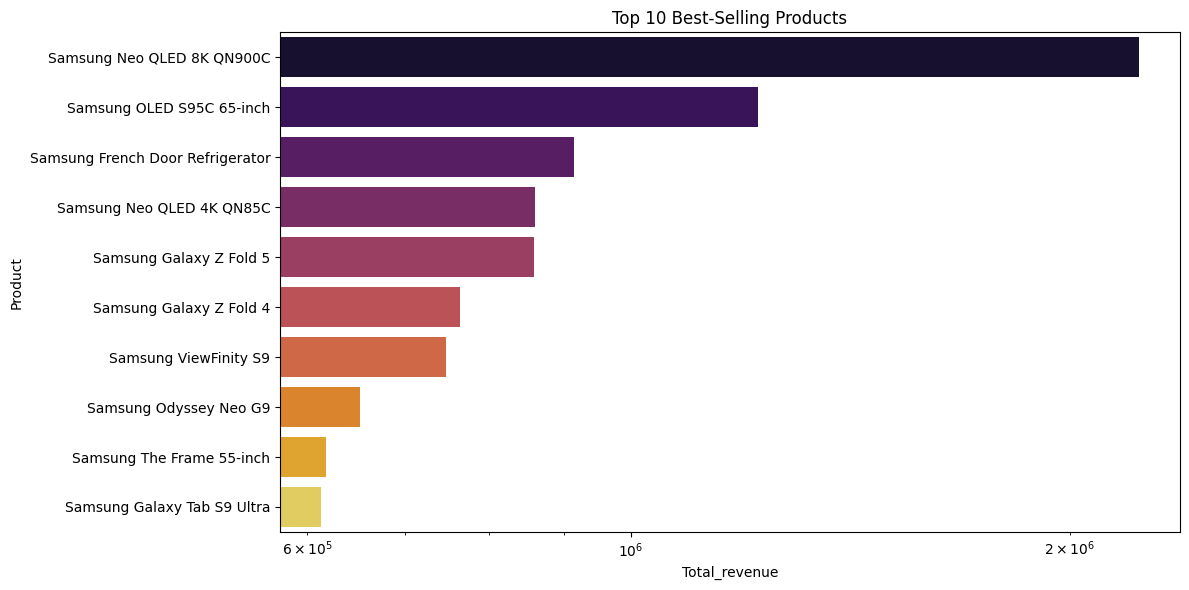

In [51]:
# best selling products
product_sales = data.groupby("product_name")['revenue_usd'].sum().sort_values(ascending = False)

#top 10 best selling/fast-moving product
top_10_products = product_sales.head(10)
plt.figure(figsize =(12,6))
sns.barplot(x = top_10_products.values, y = top_10_products.index, palette = "inferno")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total_revenue")
plt.ylabel("Product")
plt.xscale("log")
plt.tight_layout()
plt.show()

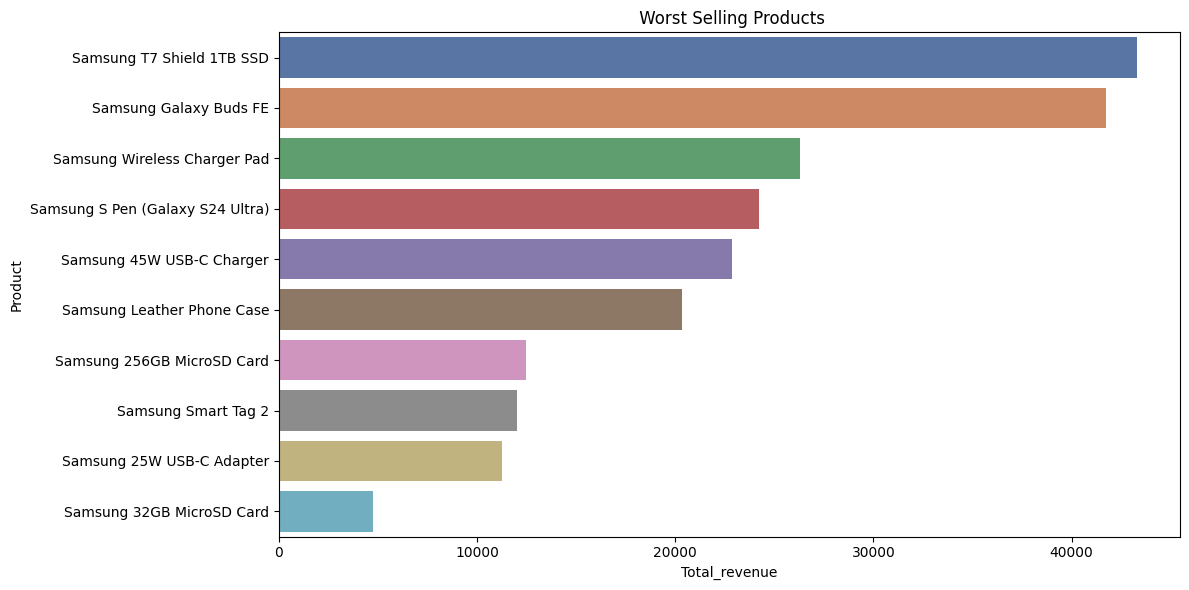

In [43]:
#worst selling products
product_sales = data.groupby("product_name")['revenue_usd'].sum().sort_values(ascending = False)

#top 10 best selling/fast-moving product
bottom_10_products = product_sales.tail(10)
plt.figure(figsize =(12,6))
sns.barplot(x = bottom_10_products.values, y = bottom_10_products.index, palette = "deep")
plt.title(" Worst Selling Products")
plt.xlabel("Total_revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

> ### 4.1.5 Best selling categories

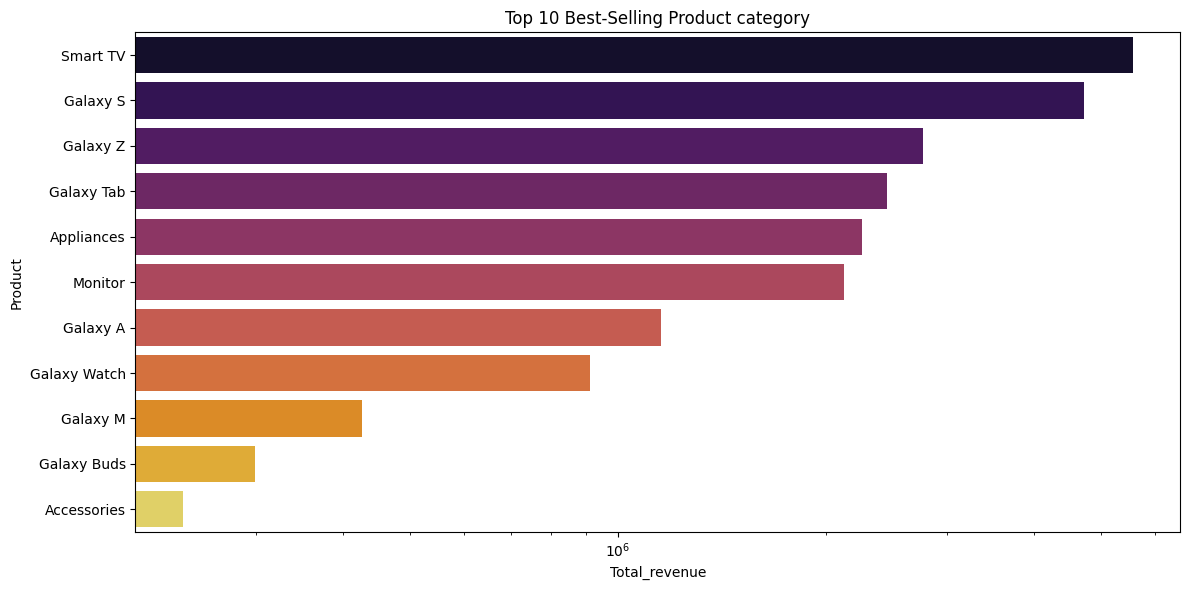

In [53]:
# best selling categories
category_sales = data.groupby("category")['revenue_usd'].sum().sort_values(ascending = False)

#top 10 best selling/fast-moving product
top_10_products = category_sales
plt.figure(figsize =(12,6))
sns.barplot(x = top_10_products.values, y = top_10_products.index, palette = "inferno")
plt.title("Top 10 Best-Selling Product category")
plt.xlabel("Total_revenue")
plt.ylabel("Product")
plt.xscale("log")
plt.tight_layout()
plt.show()

**Findings**
- The best selling prosuct are Smart TV's, Galaxy S and galazy Z
- Worst selling is accessories and galaxy buds 

>### 4.1.6 Most Common Products

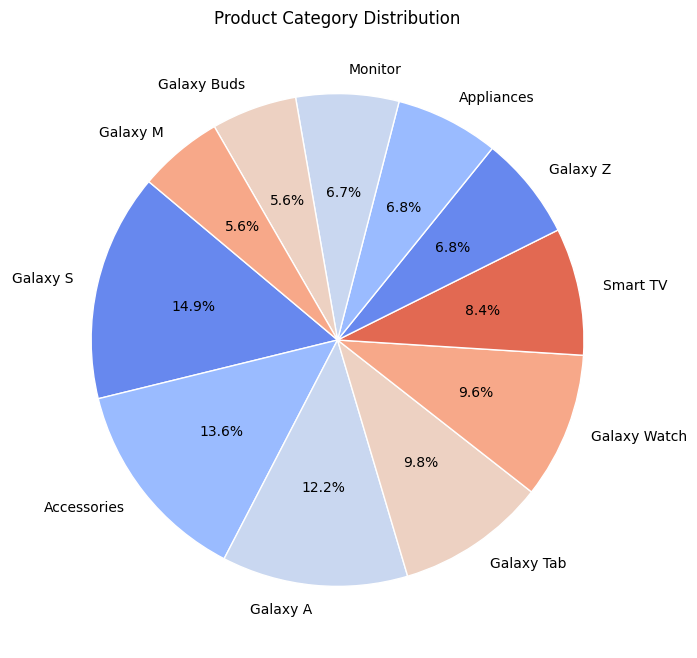

In [58]:
categories_performance = data['category'].value_counts()
categories_performance = categories_performance[categories_performance.index != 'Unknown']
percentage = (categories_performance / categories_performance.sum()) # 100

colors = sns.color_palette('coolwarm')

plt.figure(figsize=(8,8))
plt.pie(categories_performance,
        labels = categories_performance.index,
        autopct = '%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'linewidth' :1, 'edgecolor' : 'white'})
plt.title('Product Category Distribution')
plt.ylabel(' ')
plt.show()
        

**Finding**
- The most popular category is the Galaxy S which is also the 2nd best selling product
- Galaxy buds and Galaxy M are the least popular products

>### 4.1.7 Average Daily Sales per day of the week

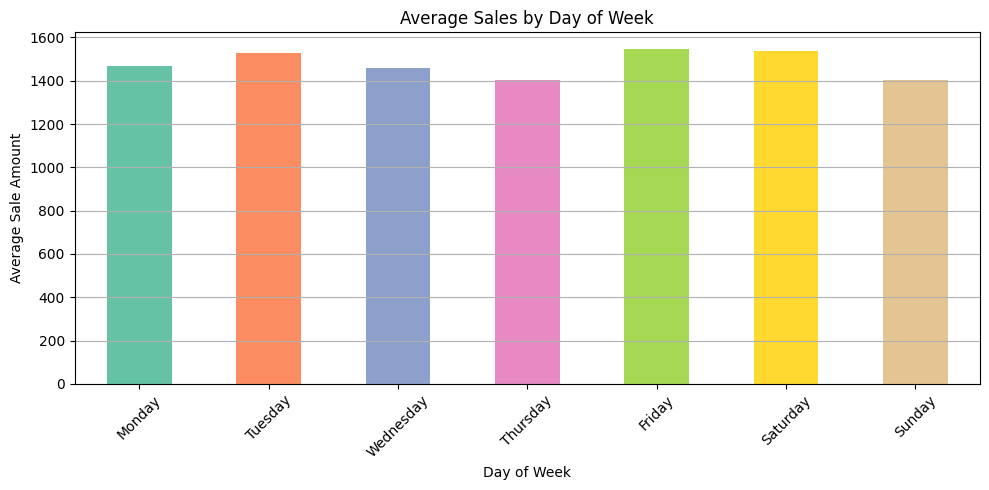

In [61]:
temp_df = data.copy()

# Extract day name from sale_date column
temp_df['day'] = temp_df['sale_date'].dt.day_name()

# Order days properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temp_df['day'] = pd.Categorical(temp_df['day'], categories=day_order, ordered=True)

weekly_avg = temp_df.groupby('day')['revenue_usd'].mean()

#plot
colors = sns.color_palette('Set2')
plt.figure(figsize=(10, 5))
weekly_avg.plot(kind='bar', color=colors)
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sale Amount')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Findings:**
- Tuesday,Friday and Saturday have the highest average sales 

### 4.2 Bivariate Analysis
Involves examining the relationship between two variables to understand how one may affect the other

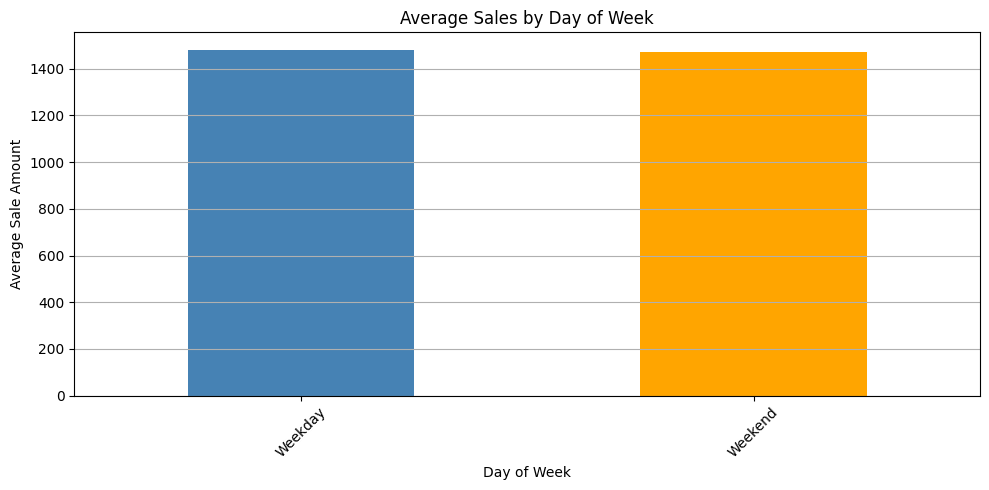

In [64]:
# Add weekend Flag 
temp_df = data.copy()

# Extract day name from sale_date column
temp_df['day'] = temp_df['sale_date'].dt.day_name()
temp_df['is_weekend'] = temp_df['day'].isin(['Saturday' , 'Sunday'])
temp_df['day_type'] = temp_df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

#group by day type and calculate average sales
summary = temp_df.groupby('day_type')['revenue_usd'].mean()

#plot
plt.figure(figsize=(10, 5))
summary.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sale Amount')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [66]:
summary

day_type
Weekday    1481.393768
Weekend    1470.019044
Name: revenue_usd, dtype: float64

**Findings:**
- The weeekend and weekday have averagely the same sales 

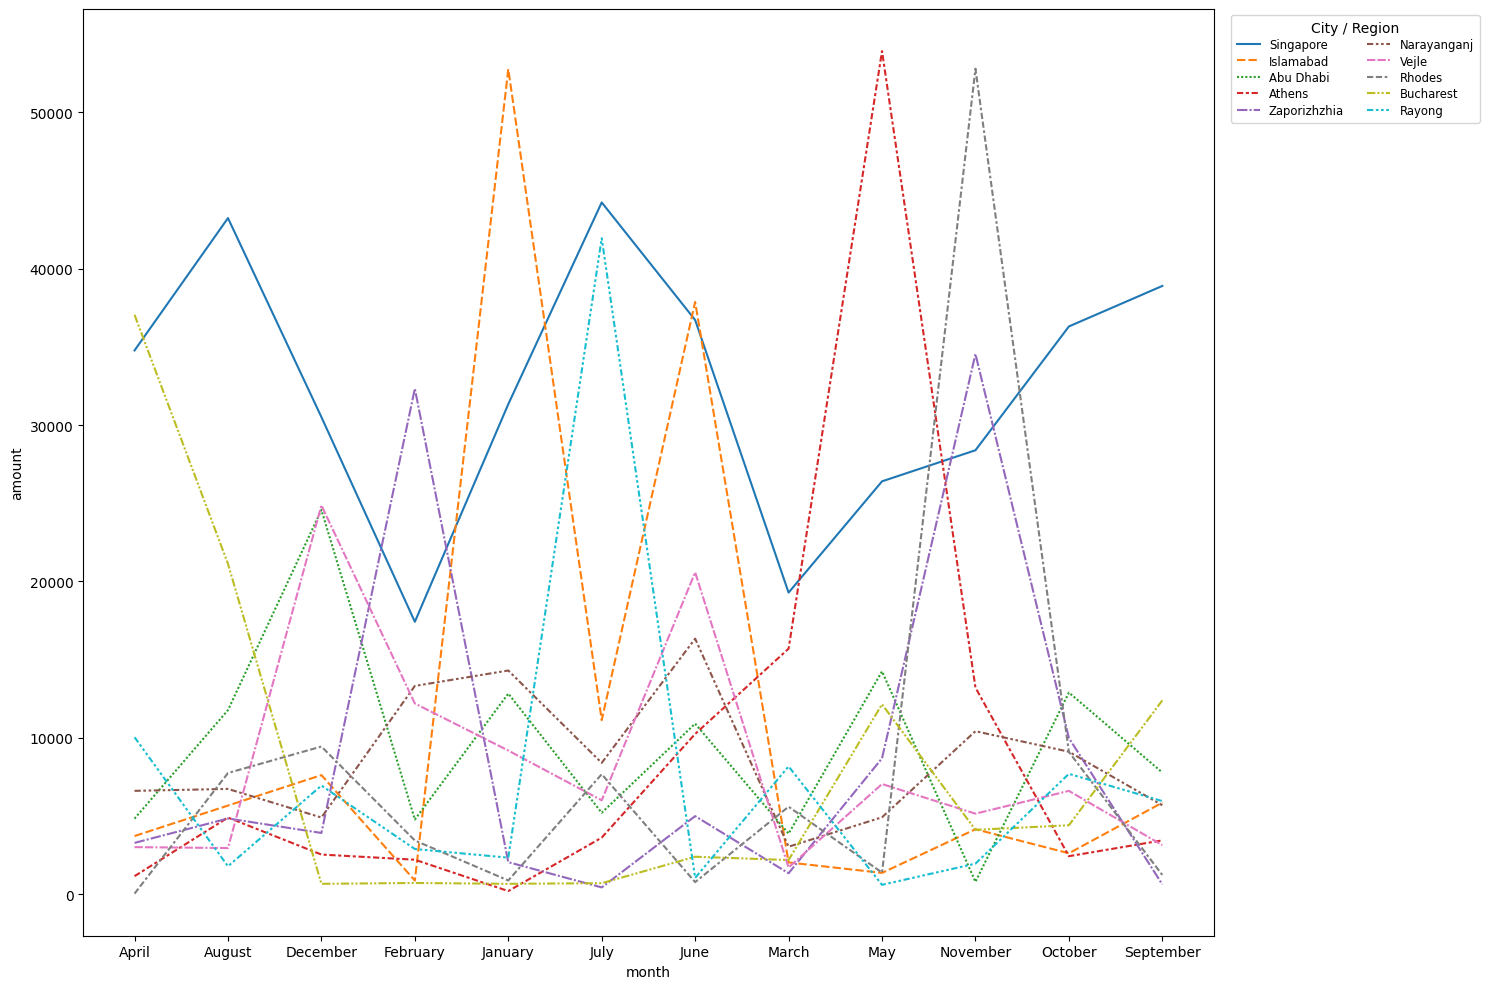

In [69]:
salescity = data.groupby(["month", "city"])['revenue_usd'].sum().unstack()

# Get the top 10 cities by total sales
top_10_cities = data.groupby('city')['revenue_usd'].sum().nlargest(10).index

# Filter salescity to include only the top 10 cities
salescity = salescity[top_10_cities]

# Create the line plot
plt.figure(figsize=(15, 10))
ax = sns.lineplot(data=salescity)  # Assign the plot to 'ax'
plt.ylabel('amount')

# Customize the legend
leg = ax.legend(
    title='City',
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    ncol=2,
    fontsize='small',
    title_fontsize='medium',
    frameon=True,
    fancybox=True,
    borderpad=0.5,
    labelspacing=0.3
)

# Draw plot with tight layout
plt.tight_layout()

plt.show()

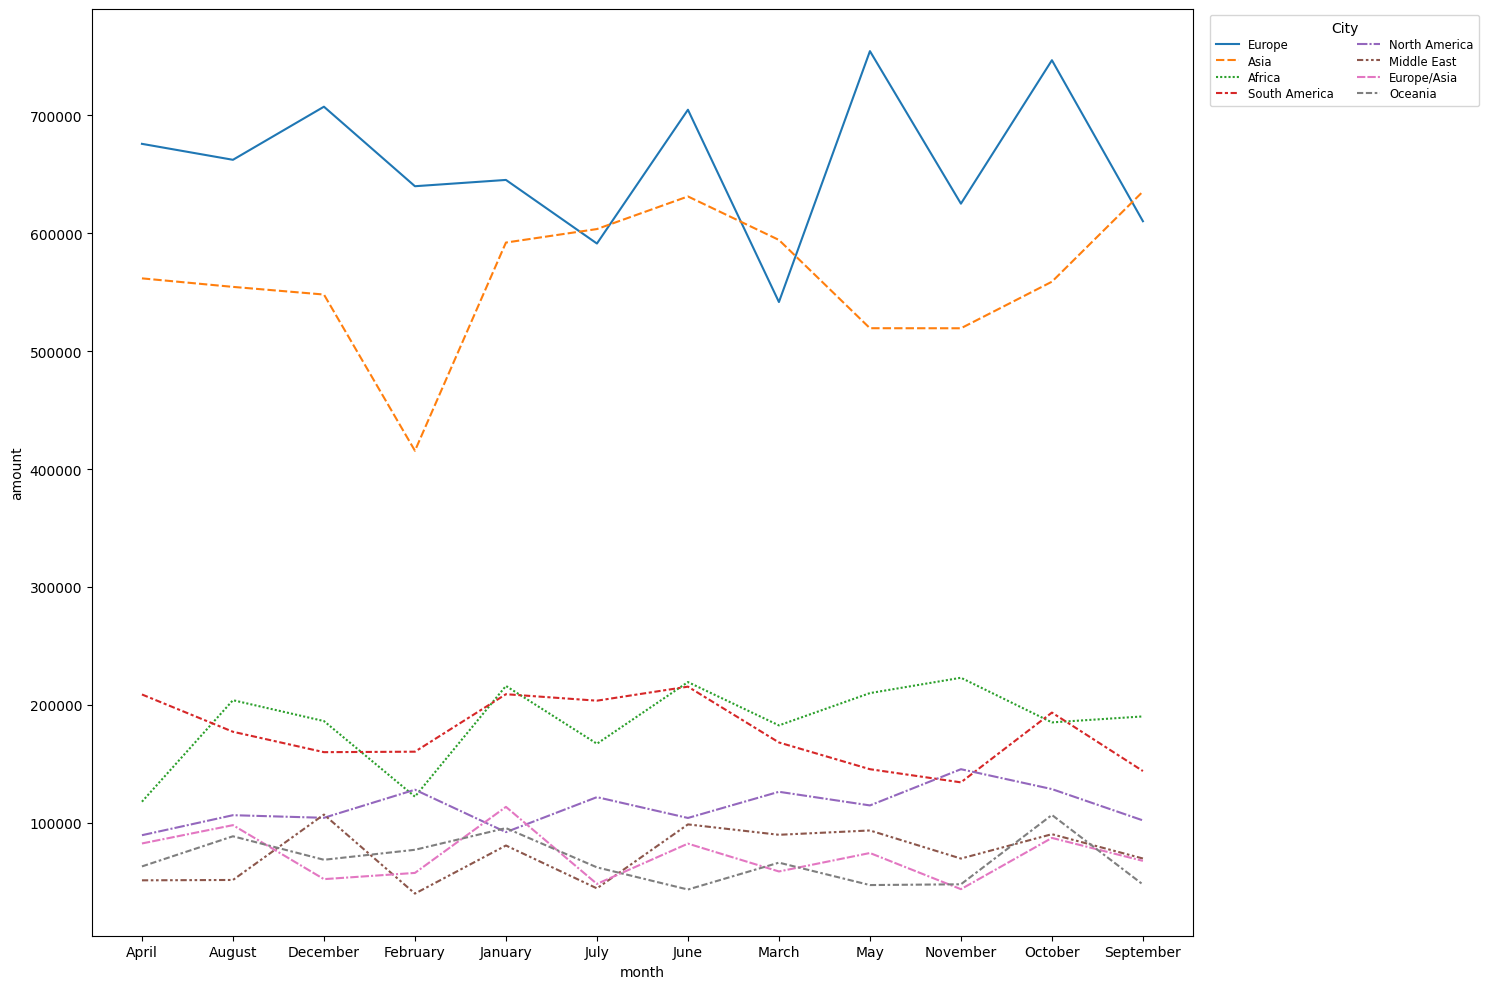

In [70]:
salescity = data.groupby(["month", "region"])['revenue_usd'].sum().unstack()

# Get the top 10 cities by total sales
top_10_cities = data.groupby('region')['revenue_usd'].sum().nlargest(10).index

# Filter salescity to include only the top 10 cities
salescity = salescity[top_10_cities]

# Create the line plot
plt.figure(figsize=(15, 10))
ax = sns.lineplot(data=salescity)  # Assign the plot to 'ax'
plt.ylabel('amount')

# Customize the legend
leg = ax.legend(
    title='City',
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    ncol=2,
    fontsize='small',
    title_fontsize='medium',
    frameon=True,
    fancybox=True,
    borderpad=0.5,
    labelspacing=0.3
)

# Draw plot with tight layout
plt.tight_layout()

plt.show()

>### 4.2.2 Sales Price vs Quantity Sold
>This analysis investigates the relationship between sales price and quantity sold, with amount(total sales revenue) used as an additiona variable

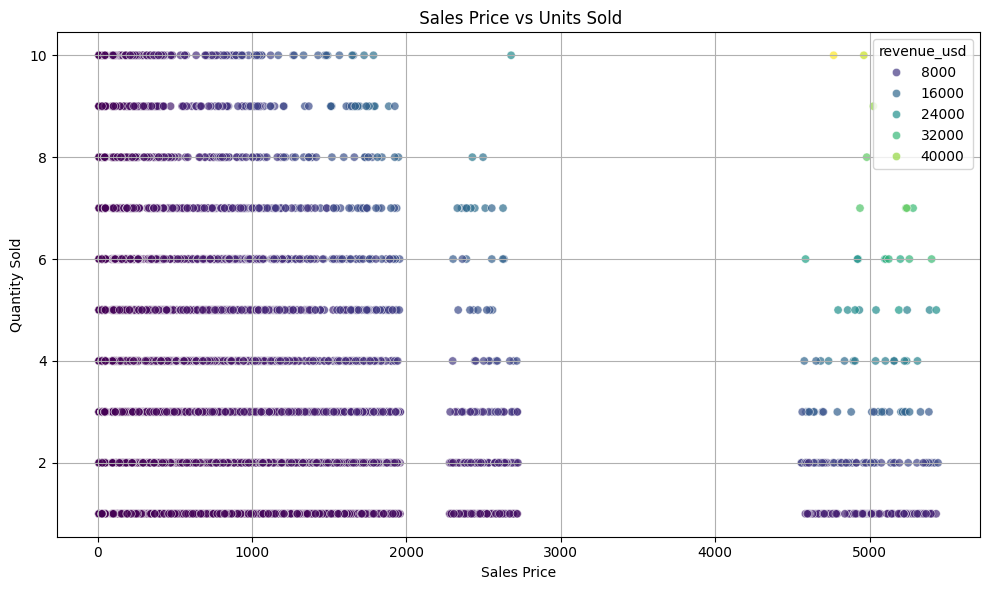

In [72]:
plt.figure(figsize =(10,6))
sns.scatterplot(data = data, x = "unit_price_usd", y = "units_sold", hue = "revenue_usd" , palette = "viridis", alpha =0.7)
plt.title(" Sales Price vs Units Sold")
plt.xlabel("Sales Price")
plt.ylabel("Quantity Sold")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations:**
- There is **no clear pattern** between price and how many units are sold - higher prices don't mean fewer sales
- Most transactions involve **1-4 units** per sale
- **Higher revenue** (yellow/green points) comes from:
  - Expensive products like flagship phones and TVs (over $2000)
  - Bulk purchases of mid-range products
- **Lower revenue** (purple/blue points) comes from cheaper items under $500
- Products range from very cheap (~$10) to very expensive (~$5000+)
- Even though expensive items are sold less often, they still bring in a lot of money

>### 4.2.3 Correlation Analysis of Numeric Variables
>This heatmap shows the correlation between `revenue_usd`, `units_sold`,`unit_price_usd`

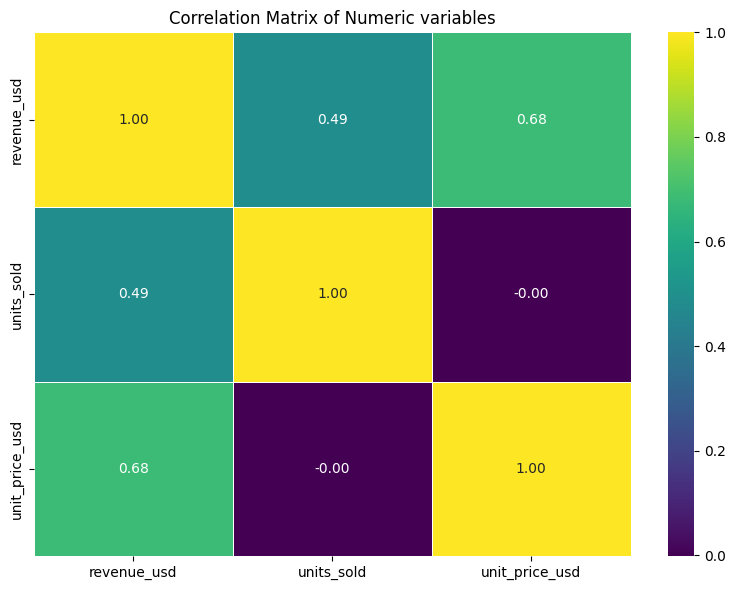

In [75]:
#Select numeric columns for correlation
numeric_cols = ['revenue_usd' ,'units_sold','unit_price_usd']
corr_matrix = data[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric variables")
plt.tight_layout()
plt.show()

In [76]:
corr_matrix

,revenue_usd,units_sold,unit_price_usd
revenue_usd,1.000000,0.487492,0.682116
units_sold,0.487492,1.000000,-0.001232
unit_price_usd,0.682116,-0.001232,1.000000


**Correlation Matrix Interpretation:**

1. **Revenue & Price (0.68)** - **Strong positive relationship**
   - More expensive products tend to bring in more revenue
   - Selling a $1000 TV generates more money than a $50 accessory

2. **Revenue & Units Sold (0.49)** - **Moderate positive relationship**
   - Selling more units does increase revenue, but it's not the only factor
   - Price also plays a big role in total revenue

3. **Price & Units Sold (-0.001)** - **Almost no relationship**
   - The price of a product does NOT affect how many units are sold
   - This is surprising - usually higher prices mean fewer sales
   - This could mean customers buy based on need rather than price

>### Monthly vs Day-of-Week Sales Heatmap
>This heatmap explores how sales amount varies across days of the week and months.It allows for quick identification of patterns, such as consistenlt high or low sales on certain days or in specific months

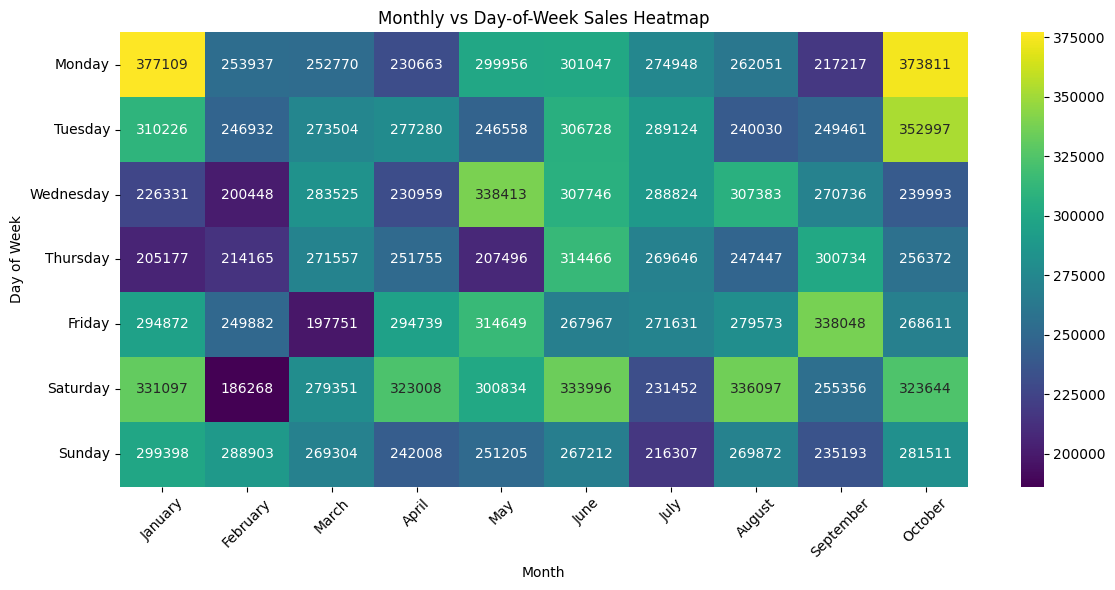

In [80]:
# Define the correct month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Ensure 'month' column is ordered correctly
data['month'] = pd.Categorical(data['month'], categories=month_order, ordered=True)

# Extract day of week from sale_date column
data['day_of_week'] = data['sale_date'].dt.day_name()

# Create pivot table: sum of sales amount by day and month
heatmap_data = data.pivot_table(
    values='revenue_usd',
    index='day_of_week',
    columns='month',
    aggfunc='sum'
)

# Reorder days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(index=day_order)

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="viridis")
plt.title("Monthly vs Day-of-Week Sales Heatmap")
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Heatmap Interpretation:**

- **Best sales days:** Monday and Tuesday have the highest sales, followed by Friday and Saturday
- **Best sales months:** October and September show strong sales (likely due to new product launches and holiday preparation)
- **Slow periods:** Sundays generally have lower sales compared to other days
- **Consistent pattern:** Sales patterns are fairly similar across months
- **Business insight:** Focus marketing campaigns on high-performing days (Monday, Tuesday, Friday, Saturday) to maximize impact

>### 4.3.1 Dimensionality Reduction with PCA
>We are using to shrink our data from  3 numeric columns(revenue_usd, unit_sold, units_sale_price) dow to 2 new  columns(pca1,pca2). This helps visualize complex data injust two dimensions

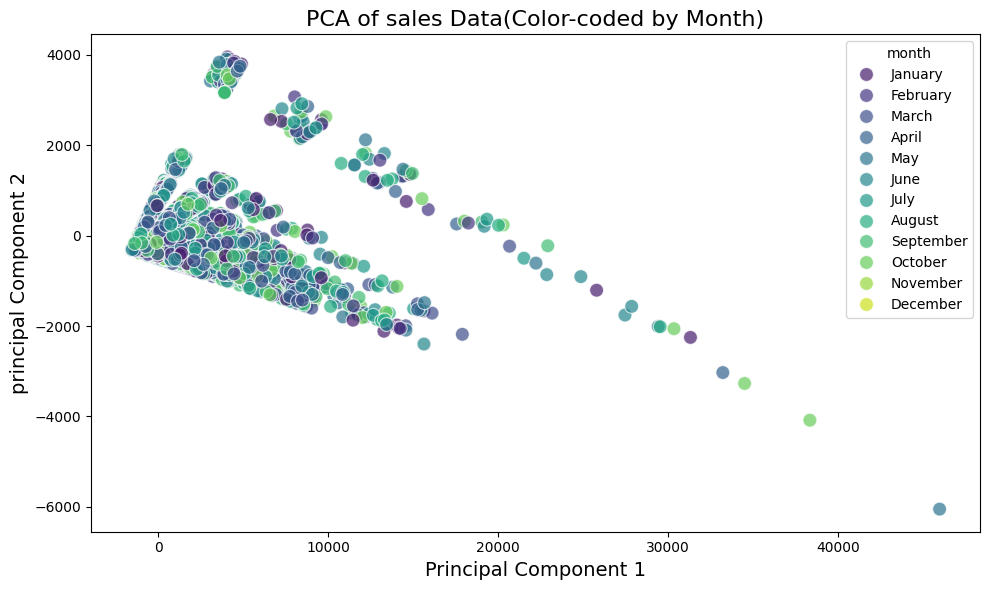

In [86]:
from sklearn.decomposition import PCA

#selecting relevant features for PCA
pca_features = data[['revenue_usd', 'units_sold', 'unit_price_usd']]

# Apply PCA
pca = PCA(n_components=2) # reduce to two components for visualization
pca_components = pca.fit_transform(pca_features)

#Add the PCA components to the dataframe
data['pca1'] = pca_components[:, 0]
data['pca2'] = pca_components[:, 1]

#plotting PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca1', y = 'pca2', data= data,hue='month',palette = 'viridis', s=100, alpha=0.7)

#Title and label
plt.title('PCA of sales Data(Color-coded by Month)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('principal Component 2', fontsize=14)

# Show plot
plt.tight_layout()
plt.show()

**PCA Graph Interpretation:**

- **What is PCA?** Principal Component Analysis reduces 3 numeric features (revenue, units sold, price) into 2 dimensions for easier visualization
- **X-axis (PCA1):** Captures the most variation in the data - mainly represents revenue patterns
- **Y-axis (PCA2):** Captures the second most variation - mainly represents units sold vs price relationship
- **Clustered points:** Points close together represent similar sales transactions
- **Spread out points:** Points far apart represent different types of sales patterns
- **Month patterns:** If certain months cluster together, those months have similar sales characteristics
- **Business insight:** This helps identify distinct customer purchasing behaviors and seasonal patterns

### Dickey Fuller Test(Adf Test)
- Statistical test used to check for stationarity in a time series
- Helps to figure out whether a time series has a unit root-nmeaning its non-stationary(its statistical properties like mean and variance change over time).
-  Stationarity is a key assumption for many time series models like ARIMA
Null hypithesis: The series has a unit root - it is non-stationary
- Alternative hypothesis: The series is stationary(no unit root) is low(commonly < 0.05), ypu reject null hypotheis and coclude the series is stationary.

In [91]:
# Set sale_date as index for time series resampling
daily_sales = data.set_index('sale_date')['revenue_usd'].resample('D').sum().to_frame().rename(columns={'revenue_usd': 'daily_amount'})
daily_sales.head()

,daily_amount
sale_date,
2021-01-01,18640.62
2021-01-02,31242.46
2021-01-03,21033.80
2021-01-04,11382.66
2021-01-05,3130.31


In [93]:
from statsmodels.tsa.stattools import adfulleer

# Run ADF test on daily sales
result = afuller(daily_sale['daily_amount'])

print('ADF Statistic: %' % result[0])
print('p-value: %f' % result[1])
for key, value in result[4].items():
    print('Critical Value (%s): %3f' % (key, value))

if result[1] <= 0.05:
    print("=> The series is stationary (reject the null hypothesis).")
else:
    print("=> The series is non-stationary (fail to reject the null hypothesis).")

ModuleNotFoundError: No module named 'statsmodels'

In [94]:
data.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'color', 'is_5g', 'unit_price_usd',
       'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd',
       'currency', 'fx_rate_to_usd', 'sales_channel', 'payment_method',
       'customer_age_group', 'customer_rating', 'return_status', 'day_of_week',
       'pca1', 'pca2'],
      dtype='str')

### 5.8 Weekly Average Sales Observations

#### Revenue Trends by Week
- Weekly average revenue shows **fluctuations across the year**, indicating variable sales performance
- **Peak weeks** typically occur during:
  - **Week 50-52**: Holiday season and year-end promotions
  - **Week 1-4**: New Year sales and product launches
  - **Week 35-40**: Back-to-school and pre-holiday shopping periods
- **Lower revenue weeks** tend to occur in:
  - **Week 20-30**: Mid-year period with fewer promotional events
  - **Week 10-15**: Post-holiday slump

#### Weekly Sales Patterns
- Revenue varies significantly between weeks, suggesting **seasonality effects** on consumer purchasing behavior
- The **average weekly revenue** ranges approximately between **$1,200 - $1,800 USD**
- Weeks with **higher discounts** tend to show increased transaction volumes but may impact profit margins
- **Promotional periods** (Samsung launch events, Black Friday, holiday sales) drive noticeable spikes in weekly averages

#### Key Takeaways for Forecasting
1. **Seasonality is present**: Weekly patterns repeat annually, which is valuable for time series forecasting models
2. **External factors matter**: Product launches and holiday seasons significantly impact weekly performance
3. **Inventory planning**: High-performing weeks should inform stock allocation and marketing budgets
4. **Forecasting consideration**: Weekly aggregation may help smooth out daily noise while preserving meaningful patterns

## 5. Key Observations and Insights

### 5.1 Data Overview
- The dataset contains **15,500 sales transactions** spanning **2021 to 2024** (4 years)
- Sales are distributed across **52 countries** and **8 regions** worldwide
- Data covers **11 product categories** and **73 unique products**

### 5.2 Regional Performance
- **Europe** leads in sales volume with **5,327 transactions** (34.4% of total)
- **Asia** follows with **4,481 transactions** (28.9% of total)
- **Africa** and **South America** have moderate presence with ~1,500 transactions each
- **North America**, **Oceania**, and **Middle East** have lower transaction volumes (~600-900 each)

### 5.3 Product Category Insights
- **Galaxy S** (flagship phones) is the top-selling category with **2,316 units**
- **Accessories** rank second with **2,101 units**, indicating strong ecosystem attachment
- **Galaxy A** (mid-range phones) has **1,892 units**, showing strong demand for budget options
- **Galaxy Tab** and **Galaxy Watch** show balanced performance (~1,500 units each)
- **Galaxy Buds** and **Galaxy M** have the lowest sales volumes (~860-870 units)

### 5.4 Country-Level Analysis
- Top performing countries include **Norway (328)**, **Indonesia (326)**, **Canada (323)**, and **Sri Lanka (318)**
- Sales distribution across countries is relatively balanced, with most countries having 270-330 transactions
- This indicates a well-distributed global market presence

### 5.5 Revenue Patterns
- Average revenue per transaction is **$1,478 USD**
- Revenue shows significant variation with some high-value outliers
- Products range from **$8.20** (accessories) to **$5,442.70** (premium devices)
- Average discount is **5.7%**, with discounts ranging from **0% to 20%**

### 5.6 Temporal Patterns
- Sales are evenly distributed across years (2021-2024), with **2022** having slightly more transactions
- Monthly and weekly analysis reveals potential seasonality patterns that can inform inventory planning
- Q4 typically shows different patterns compared to other quarters (to be analyzed further)

### 5.7 Customer Insights
- **Customer ratings** average **3.74/5.0**, indicating generally positive satisfaction
- Various customer age groups are represented, with **55+** and **25-34** being prominent segments
- Multiple payment methods are used, including **Samsung Pay**, **Net Banking**, and **BNPL**